
# dGen Results — streamlined analysis

This notebook demonstrates a clean, single‑pass workflow built around
`DataWarehouse` and the revised coincident‑peak metrics.

> **Tip:** Edit `ROOT_DIR` and `RUN_ID` to point at your run directory.


In [2]:
import sys, os
sys.path.append(os.path.abspath("../"))

In [3]:

from pathlib import Path
import importlib

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import analysis_functions as af
importlib.reload(af)  # safe reload during editing

sns.set_context("talk")
sns.set_style("whitegrid")

ROOT_DIR = "/Users/wael/Documents/dgen_runs"      
RUN_ID   = "run_nc_single_state" 
STATES   = ["NC"]              
cfg = af.SavingsConfig(lifetime_years=25, cap_to_horizon=False)
#states = gpd.read_file("../../../data/states.shp")


## 1) Load once

In [4]:
wh = af.DataWarehouse.from_disk(ROOT_DIR, run_id=RUN_ID, states=STATES)

## 2) Aggregations and peaks

In [5]:
outputs = af.aggregate_state_metrics(wh.agents, cfg)
peaks   = af.compute_peaks_by_state(wh.state_hourly)


## 3) Coincident peak reduction — *top‑10 baseline hours* (recommended)

In [6]:

rto_co_top10 = af.compute_rto_coincident_reduction(
    wh, method="baseline_topN_avg", top_n=10, return_by_rto=False
)

## 4) National lines (with coincident delta panel)

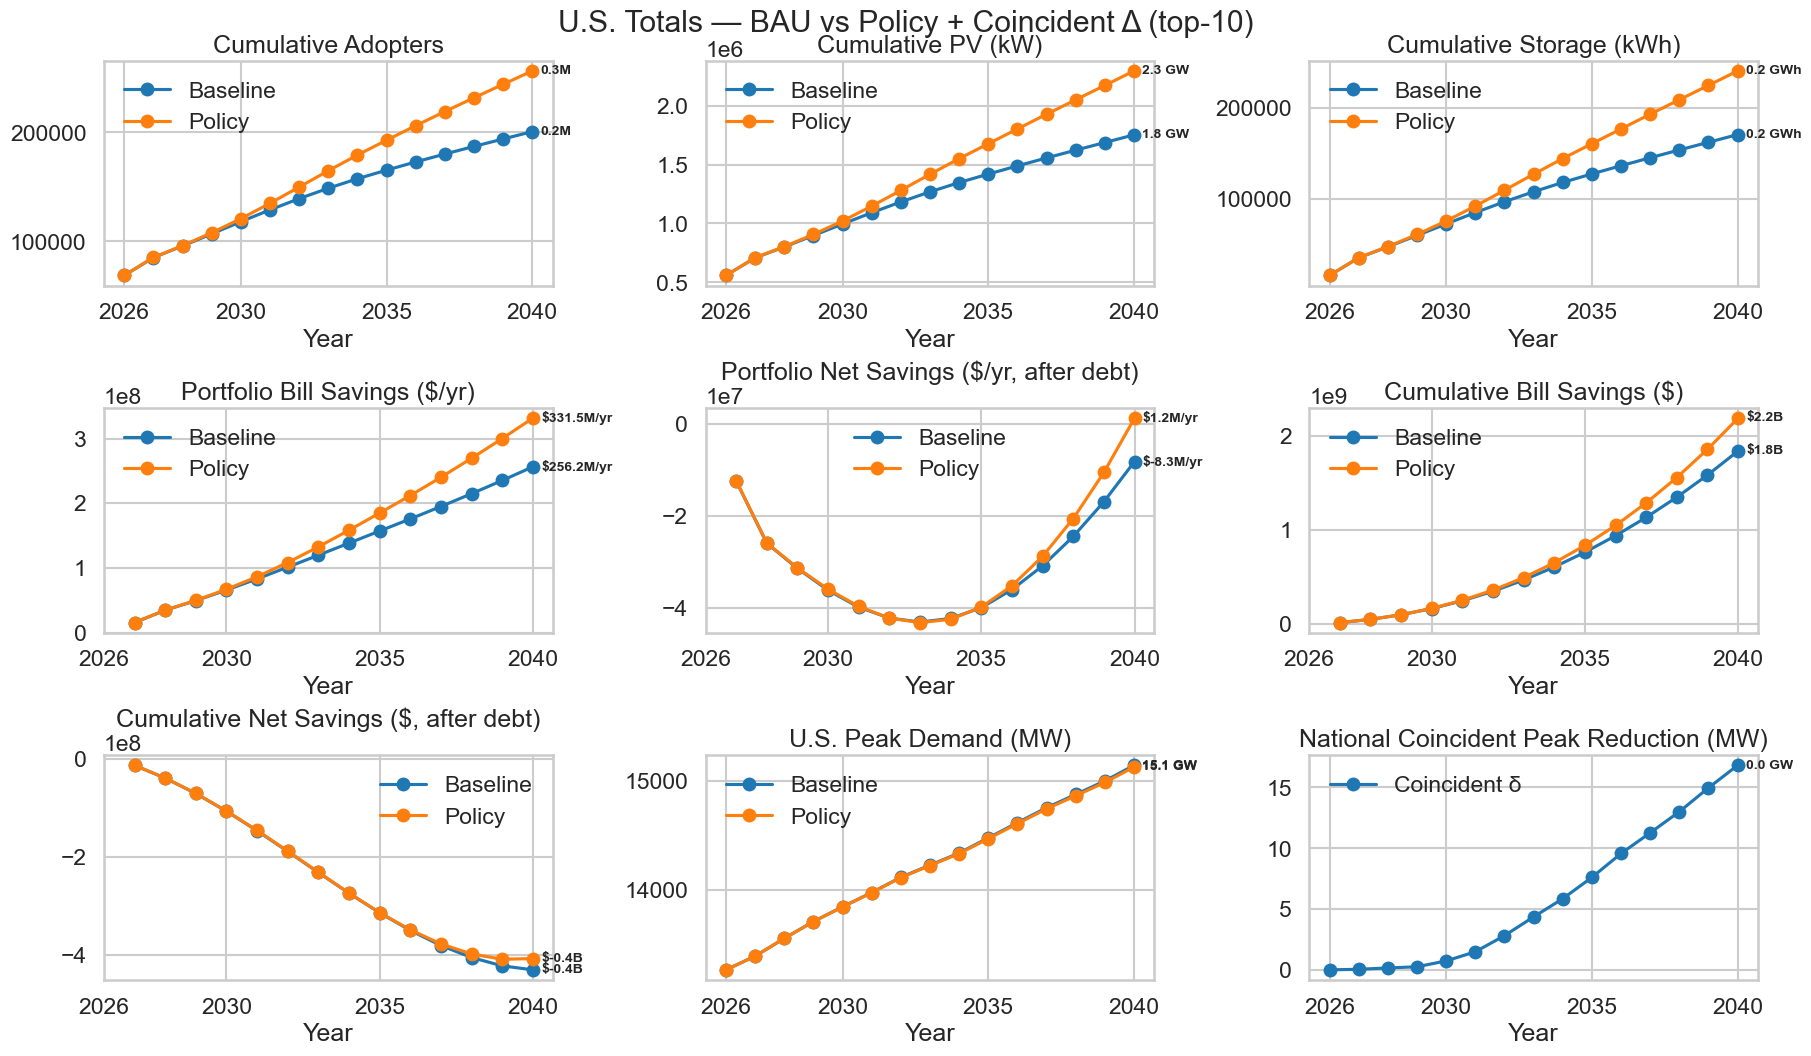

In [7]:

af.facet_lines_national_totals(
    outputs=outputs,
    peaks_df=peaks,
    coincident_df=rto_co_top10,
    title="U.S. Totals — BAU vs Policy + Coincident Δ (top-10)",
    ncols=3,
)


## 5) Sensitivity: alternative coincident metrics

In [ ]:
# co_single   = af.compute_rto_coincident_reduction(wh, method="single_hour")
# co_sep_topN = af.compute_rto_coincident_reduction(wh, method="separate_topN_means", top_n=10)

In [ ]:
# af.facet_choropleth_payback_continuous(warehouse=wh, shapefile_path="../../../data/states.shp", year=2040, agents=wh.agents)

findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font family 'Cabin' not found.
findfont: Font f

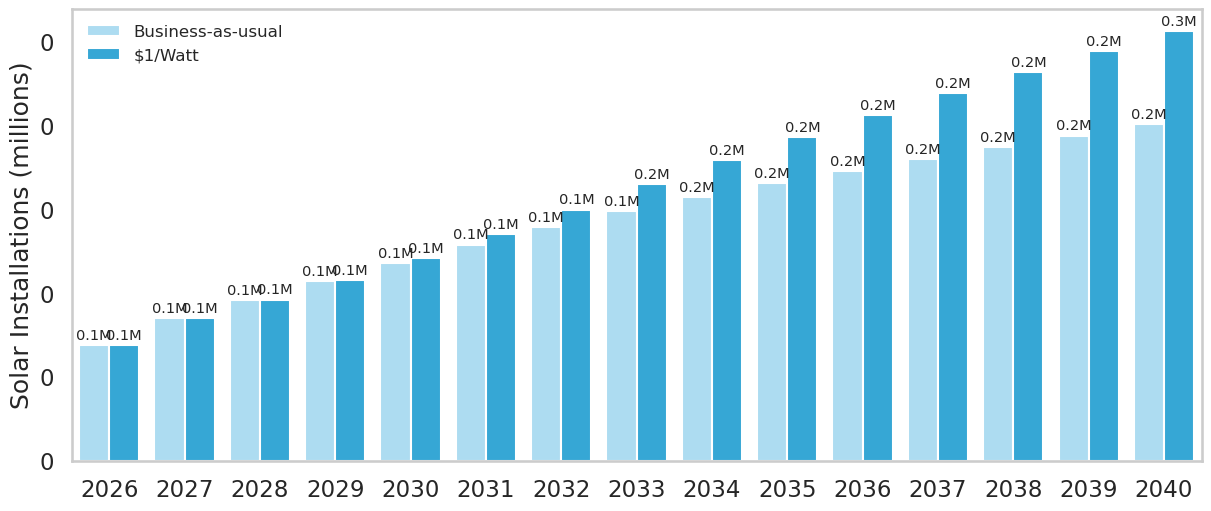

In [8]:
af.plot_us_cum_adopters_grouped(outputs)

In [ ]:
af.bar_us_net_savings_median_2040_from_agents(
    warehouse=wh, agents = wh.agents, title=""
)

In [ ]:
af.plot_us_payback_customers_weighted_over_time(
    warehouse = wh, agents = wh.agents
)

In [ ]:
# if STATES is None:
#     af.choropleth_pct_households_with_solar(outputs, "../../../data/states.shp", year=2040)
# else: 
#     pass

In [ ]:
# if STATES is None:
#     af.choropleth_state_coincident_reduction(
#         warehouse=wh, shapefile_path="../../../data/states.shp", 
#         year=2040, method="baseline_topN_avg", top_n=10)
# else: 
#     pass

In [9]:
eabs_states = af.build_eabs_calendar_timeseries(warehouse=wh)
eabs_us = af.build_eabs_calendar_timeseries(warehouse=wh, level="us")
eabs_states

,geo,scenario,year,adopters_active,avg_bill_with,avg_bill_wo,eabs,pct_savings,avg_debt,eabs_net,pct_net_vs_wo
0,NC,baseline,2026,13933.258558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,NC,baseline,2027,30300.204990,126.615311,627.373774,500.758463,0.798182,915.809828,-415.051365,-0.661570
2,NC,baseline,2028,40973.146175,209.507581,1045.432858,835.925277,0.799597,1475.744708,-639.819431,-0.612014
3,NC,baseline,2029,52074.307104,238.699891,1179.994627,941.294736,0.797711,1550.848663,-609.553927,-0.516573
4,NC,baseline,2030,63214.258441,264.462017,1296.457006,1031.994989,0.796012,1610.226074,-578.231085,-0.446009
5,NC,baseline,2031,74074.972258,288.244164,1402.394688,1114.150524,0.794463,1658.323331,-544.172807,-0.388031
6,NC,baseline,2032,84378.248050,311.312898,1503.001056,1191.688157,0.792872,1698.264027,-506.575870,-0.337043
7,NC,baseline,2033,93917.648155,334.229628,1601.261175,1267.031547,0.791271,1731.975117,-464.943570,-0.290361
8,NC,baseline,2034,102637.943794,357.019464,1697.591453,1340.571988,0.789691,1759.198507,-418.626519,-0.246600
9,NC,baseline,2035,110534.334173,380.235346,1793.730740,1413.495395,0.788020,1781.381013,-367.885618,-0.205095


In [10]:
annual, cumulative, lifetime = af.compute_portfolio_and_cumulative_savings(wh.agents, cfg)

nat_ts = af.build_us_cumulative_timeseries(annual, lifetime_df=lifetime, xticks_full=True)

# e.g., get 2040 numbers
nat_2040 = af.summarize_us_cumulative_for_year(nat_ts, 2040)
print(nat_2040)

   scenario  year  cumulative_bill_savings_us  cumulative_net_savings_us  \
0  baseline  2040                1.839715e+09              -4.304629e+08   
1    policy  2040                2.188601e+09              -4.075140e+08   

   lifetime_net_after_upfront_total_us  
0                         1.029759e+08  
1                         9.967786e+08  


## 6) Optional: export tidy tables

In [11]:
out_path = af.export_compiled_results_to_excel(outputs, run_id=RUN_ID or "run", out_dir=ROOT_DIR,
                                              peaks_df=peaks, coincident_df=rto_co_top10)